<a href="https://colab.research.google.com/github/arnavvvyyy/Calculator-app/blob/main/Uber_project_SQL_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure charts show up beautifully in Colab
%matplotlib inline
sns.set_theme(style="whitegrid") # Adds a clean background to our charts

# 🛑 FIX: Use read_excel instead of read_csv for an .xlsx file!
df = pd.read_excel('Uber Request Data.xlsx')

# Let's look at the first 5 rows to make sure it loaded correctly
df.head()

,Request id,Pickup point,Driver id,Status,Request Date,Request Time,Drop Date,Drop time
0,619,Airport,1.0,Trip Completed,2016-11-07,11:51:00,2016-07-11,13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07,17:57:00,2016-07-11,18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07,09:17:00,2016-07-12,09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07,21:08:00,2016-07-12,22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13,08:33:16,2016-07-13,09:25:47


In [ ]:
print("--- Data Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Data Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Request id    6745 non-null   int64         
 1   Pickup point  6745 non-null   object        
 2   Driver id     4095 non-null   float64       
 3   Status        6745 non-null   object        
 4   Request Date  6745 non-null   datetime64[ns]
 5   Request Time  6745 non-null   object        
 6   Drop Date     2831 non-null   datetime64[ns]
 7   Drop time     2831 non-null   object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 421.7+ KB

--- Missing Values Count ---
Request id         0
Pickup point       0
Driver id       2650
Status             0
Request Date       0
Request Time       0
Drop Date       3914
Drop time       3914
dtype: int64


In [ ]:
#extracting the time

In [ ]:
# 1. Let's see exactly what your columns are named
print("Your columns are:", df.columns.tolist())

# 2. Smartly extract the hour based on whatever your column is called!
if 'Request_Time' in df.columns:
    df['Req_Hour'] = pd.to_datetime(df['Request_Time'].astype(str)).dt.hour
elif 'Request Time' in df.columns:
    df['Req_Hour'] = pd.to_datetime(df['Request Time'].astype(str)).dt.hour
elif 'Request timestamp' in df.columns:
    df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], dayfirst=True, format='mixed')
    df['Req_Hour'] = df['Request timestamp'].dt.hour
elif 'Request_timestamp' in df.columns:
    df['Request_timestamp'] = pd.to_datetime(df['Request_timestamp'], dayfirst=True, format='mixed')
    df['Req_Hour'] = df['Request_timestamp'].dt.hour
else:
    print("Wait, I couldn't find the time column! Look at the printed columns above.")

print("\nSuccess! Here is your data with the new Req_Hour column:")
print(df.head(3))

Your columns are: ['Request id', 'Pickup point', 'Driver id', 'Status', 'Request Date', 'Request Time', 'Drop Date', 'Drop time']

Success! Here is your data with the new Req_Hour column:
   Request id Pickup point  Driver id          Status Request Date  \
0         619      Airport        1.0  Trip Completed   2016-11-07   
1         867      Airport        1.0  Trip Completed   2016-11-07   
2        1807         City        1.0  Trip Completed   2016-12-07   

  Request Time  Drop Date Drop time  Req_Hour  
0     11:51:00 2016-07-11  13:00:00        11  
1     17:57:00 2016-07-11  18:47:00        17  
2     09:17:00 2016-07-12  09:58:00         9  


/tmp/ipykernel_3839/55995497.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Req_Hour'] = pd.to_datetime(df['Request Time'].astype(str)).dt.hour


/tmp/ipykernel_3839/844675919.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status', data=df, palette='Set2')


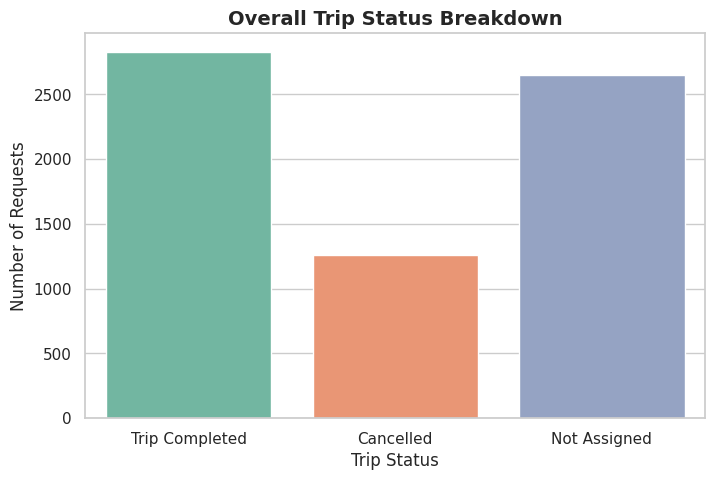

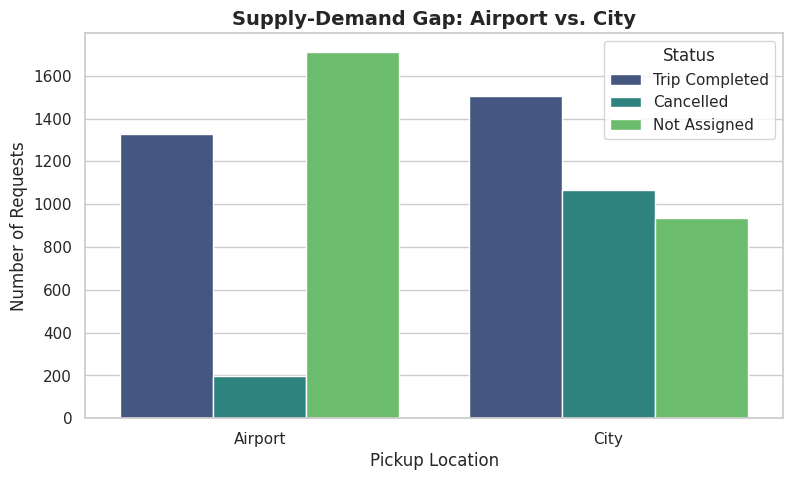

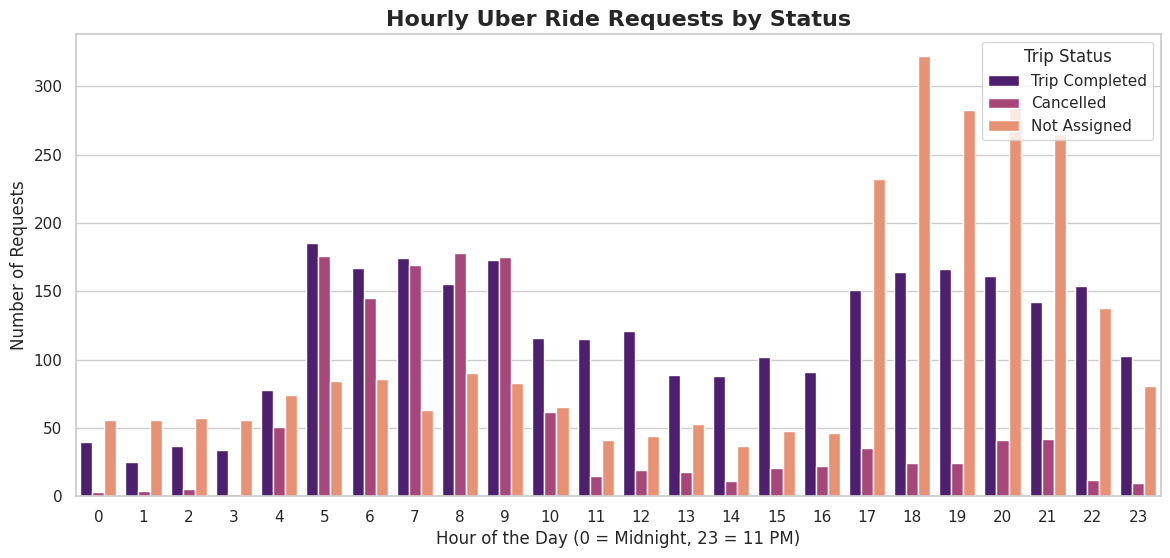

In [ ]:
#my charts
import matplotlib.pyplot as plt
import seaborn as sns

# Figure out the exact name of the Pickup column
pickup_col = 'Pickup_point' if 'Pickup_point' in df.columns else 'Pickup point'

# Chart 1: Overall Status
plt.figure(figsize=(8, 5))
sns.countplot(x='Status', data=df, palette='Set2')
plt.title('Overall Trip Status Breakdown', fontsize=14, fontweight='bold')
plt.ylabel('Number of Requests')
plt.xlabel('Trip Status')
plt.show()

# Chart 2: Airport vs City
plt.figure(figsize=(9, 5))
sns.countplot(x=pickup_col, hue='Status', data=df, palette='viridis')
plt.title('Supply-Demand Gap: Airport vs. City', fontsize=14, fontweight='bold')
plt.ylabel('Number of Requests')
plt.xlabel('Pickup Location')
plt.show()

# Chart 3: The "A+" Hourly Time-Series Chart
plt.figure(figsize=(14, 6))
sns.countplot(x='Req_Hour', hue='Status', data=df, palette='magma')
plt.title('Hourly Uber Ride Requests by Status', fontsize=16, fontweight='bold')
plt.ylabel('Number of Requests')
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)')
plt.legend(title='Trip Status', loc='upper right')
plt.show()

In [ ]:
#my sql
# 1. Install the library that lets us write SQL in Python
!pip install pandasql

# 2. Import the libraries
import pandas as pd
import pandasql as ps

# 3. Load your EXCEL file into a table named 'uber'
# (Changed to read_excel instead of read_csv)
uber = pd.read_excel('Uber Request Data.xlsx')

# 4. Quick clean-up: replace spaces in column names with underscores so SQL can read them easily
uber.columns = [c.replace(' ', '_') for c in uber.columns]

print("Setup Complete! Your SQL table name is 'uber'.")

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=519bcafb05fd88a56c15850f271b7f7ae317d879e48b2186e90114aa8954c9fe
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql
Setup Complete! Your SQL table name is 'uber'.


In [ ]:
#my query 1
query_1 = """
SELECT
    Status,
    COUNT(Request_id) AS Total_Requests,
    ROUND(COUNT(Request_id) * 100.0 / (SELECT COUNT(*) FROM uber), 2) AS Percentage
FROM
    uber
GROUP BY
    Status
ORDER BY
    Total_Requests DESC;
"""

# Run the SQL query
print(ps.sqldf(query_1, locals()))

           Status  Total_Requests  Percentage
0  Trip Completed            2831       41.97
1    Not Assigned            2650       39.29
2       Cancelled            1264       18.74


In [ ]:
#my query 2
query_2 = """
SELECT
    Pickup_point,
    Status,
    COUNT(Request_id) AS Total_Requests
FROM
    uber
GROUP BY
    Pickup_point, Status
ORDER BY
    Pickup_point, Total_Requests DESC;
"""

print(ps.sqldf(query_2, locals()))

  Pickup_point          Status  Total_Requests
0      Airport    Not Assigned            1713
1      Airport  Trip Completed            1327
2      Airport       Cancelled             198
3         City  Trip Completed            1504
4         City       Cancelled            1066
5         City    Not Assigned             937


In [ ]:
#my query 3
query_3 = """
SELECT
    -- Grab the first 2 characters of your clean Request_Time column to get the hour
    SUBSTR(CAST(Request_Time AS TEXT), 1, 2) AS Hour_of_Day,
    COUNT(CASE WHEN Status != 'Trip Completed' THEN 1 END) AS Failed_Requests,
    COUNT(Request_id) AS Total_Requests
FROM
    uber
GROUP BY
    Hour_of_Day
ORDER BY
    Failed_Requests DESC
LIMIT 5;
"""

print(ps.sqldf(query_3, locals()))

  Hour_of_Day  Failed_Requests  Total_Requests
0          18              346             510
1          20              331             492
2          21              307             449
3          19              307             473
4          08              268             423


In [ ]:
print(uber.columns)

Index(['Request_id', 'Pickup_point', 'Driver_id', 'Status', 'Request_Date',
       'Request_Time', 'Drop_Date', 'Drop_time'],
      dtype='object')
